**Import Libraries**

In [3]:
from libraries import*
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
from scipy import optimize
from scipy.optimize import curve_fit
import sympy as sym
from sympy import *
from matplotlib.lines import Line2D

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


In [4]:
w0 = 192.55 # larmor frequency for 11B
df = [0]*6
# Data for (-)8HQ(ipc)2B
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1]) #skipping row for frequency label
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1,2]) #skipping row for frequency label and angle = -7
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])

# Data for (+)8HQ(ipc)2B
df[3] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_X_Rot', skiprows=[1])
df[4] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Y_Rot', skiprows=[1])
df[5] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Z_Rot', skiprows=[1])




In [5]:
df[1].head()

,Angle,Cluster1Peak0,Cluster1Peak1,Cluster1Peak2,Cluster2Peak0,Cluster2Peak1,Cluster2Peak2,J_Cluster1,J_Cluster2,Cluster1Peak0.1,...,J_Cluster2.1,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,10,-6.824186,-3.439836,0.264127,-8.311208,-4.966250,-0.958541,3.544157,3.676333,-1313.997107,...,707.877976,NaN,NaN,NaN,NaN,Larmor frequency for 11B,NaN,NaN,192.55,MHz
1,20,-5.591119,-3.371925,-2.357396,-7.404882,-6.415516,-4.553797,1.616861,1.425543,-1076.569910,...,274.488219,NaN,NaN,NaN,NaN,NaN,NaN,1 ppm,192.55,Hz
2,30,-5.059813,-4.601466,-4.002923,-8.132726,-7.559935,-6.762679,0.528445,0.685023,-974.266916,...,131.901202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,40,-4.579981,-5.774421,-6.760646,-8.143800,-9.338425,-10.220741,-1.090333,-1.038470,-881.875343,...,-199.957452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,50,-6.547073,-8.978217,-10.860817,-8.978913,-11.562172,-13.634522,-2.156872,-2.327805,-1260.638966,...,-448.218840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**For (-,-)8HQ**

In [6]:

L_HQ_x = [[-2.243306, 1.428536, -3.522236, 0.219859, 0.004287], [-1.737070, 1.300349, 3.546710, -0.042379, -0.027416]] # coefficient from ASICS
L_HQ_y = [[-2.630916, 2.462382, 0.271774, -0.401864, -0.525906], [-2.748530, 2.593289, 1.011176, -0.325788, -0.557786]] # coefficient from ASICS
L_HQ_z = [[-3.468406, -1.138969, -0.574216, -0.939815, -1.094452], [-3.261651, -1.187894 ,-0.628636 ,-0.956962 ,-1.127200]] # coefficient from ASICS

# Fit for Mounting 1
angle_smooth = np.linspace(df[0].Angle.min(), df[0].Angle.max(), 200) #100 points for smooth curve
L_HQ_1_x = fourier5(angle_smooth, *L_HQ_x[0])
L_HQ_2_x = fourier5(angle_smooth, *L_HQ_x[1])

# Fit for Mounting 2
L_HQ_1_y = fourier5(angle_smooth, *L_HQ_y[0])
L_HQ_2_y = fourier5(angle_smooth, *L_HQ_y[1])

# Fit for Mounting 3
L_HQ_1_z = fourier5(angle_smooth, *L_HQ_z[0])
L_HQ_2_z = fourier5(angle_smooth, *L_HQ_z[1])


**Chemical Shift vs Angle**

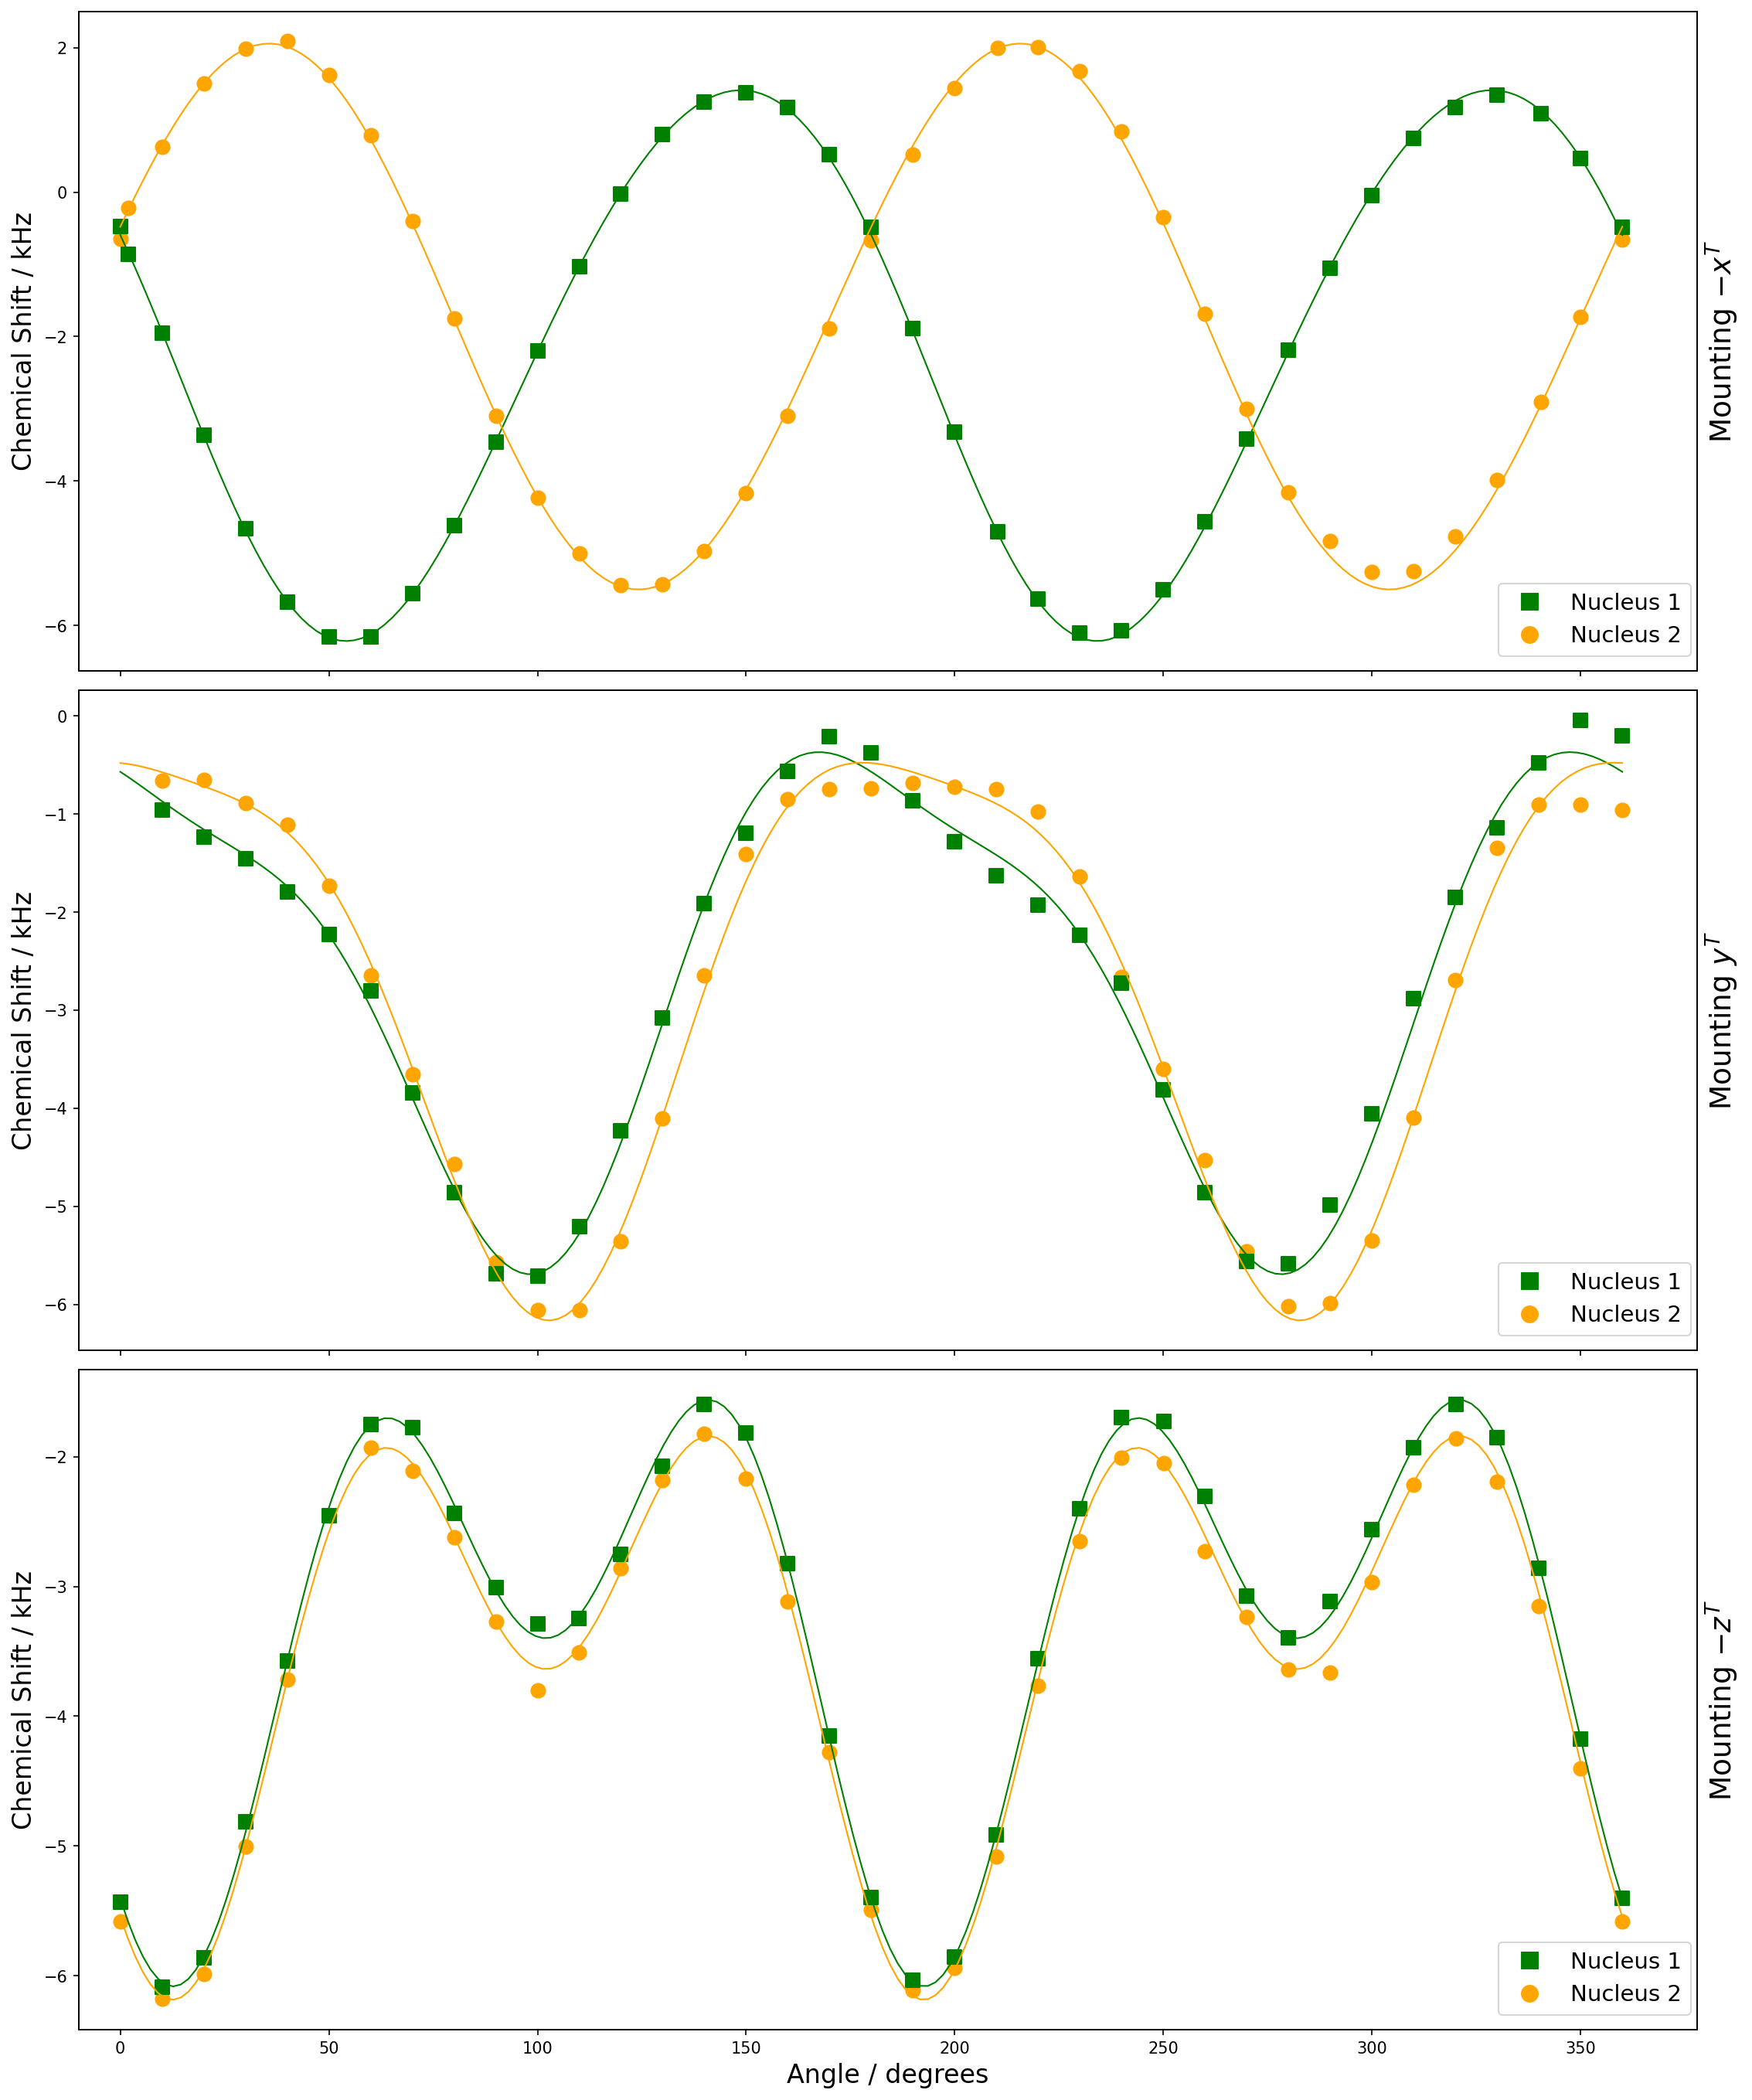

In [7]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
axes[0].scatter(df[0].Angle, df[0].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'orange') #frequency in kHz

axes[0].scatter(df[0].Angle, df[0].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'green') #frequency in kHz

axes[0].plot(angle_smooth, L_HQ_1_x,  color='green', lw = 1)

axes[0].plot(angle_smooth, L_HQ_2_x,  color='orange', lw = 1)



# Plot Mount 2 data****************************

axes[1].scatter(df[1].Angle, df[1].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'orange') #frequency in kHz

axes[1].scatter(df[1].Angle, df[1].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'green') #frequency in kHz

axes[1].plot(angle_smooth, L_HQ_1_y,  color='green', lw = 1)

axes[1].plot(angle_smooth, L_HQ_2_y,  color='orange', lw = 1)



# Plot Mount 3 data****************************

axes[2].scatter(df[2].Angle, df[2].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'orange') #frequency in kHz

axes[2].scatter(df[2].Angle, df[2].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'green') #frequency in kHz

axes[2].plot(angle_smooth, L_HQ_2_z,  color='green', lw = 1)

axes[2].plot(angle_smooth, L_HQ_1_z,  color='orange', lw = 1)

# Set x-axis label
plt.xlabel('Angle / degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[1].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[2].set_ylabel('Chemical Shift / kHz', fontsize=16)

# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel(r'Mounting $-x^T$', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel(r'Mounting $y^T$', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel(r'Mounting $-z^T$', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='g', markersize=12, label='Nucleus 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=12, label='Nucleus 2'),
                 
                 ]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0.87, 0.15), fontsize = 14, ncol=1)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0.87, 0.15), fontsize = 14, ncol=1)
axes[2].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0.87, 0.15), fontsize = 14, ncol=1)
ax0_twin.set_xlim(left=-10)

Fig.savefig('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/LHQ_rotation_plot.png', dpi = 150 ,bbox_inches='tight')

# Show the plot
plt.show()


**JJ Coupling vs Angle**

In [8]:
# Basic imports
import os, sys
sys.path.insert(0, os.path.abspath('..')) # This to add the Soprano path to the PYTHONPATH
                                          # so we can load it without installing it
import ase
from ase import io as ase_io
HQ_J = ase_io.read('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/CASTEP/8-HQ-ipc2-B_opt_magres_J_new.magres')

In [9]:
# getting labels from magres file
labels = HQ_J.get_array('labels')
indices = HQ_J.get_array('indices')
B_i = np.where(labels == 'B')
B = HQ_J[B_i]

print('There are {0} boron atoms'.format(len(B)))
# One can also recreate the Jmol/MagresView-style labels if needed:
jmol_labels = ["{0}_{1}".format(l, i) for l, i in zip(labels, indices)]

print("The labels are {0}".format(', '.join(jmol_labels)))

There are 1 boron atoms
The labels are H_1, H_2, H_3, H_4, H_5, H_6, H_7, H_8, H_9, H_10, H_11, H_12, H_13, H_14, H_15, H_16, H_17, H_18, H_19, H_20, H_21, H_22, H_23, H_24, H_25, H_26, H_27, H_28, H_29, H_30, H_31, H_32, H_33, H_34, H_35, H_36, H_37, H_38, H_39, H_40, H_41, H_42, H_43, H_44, H_45, H_46, H_47, H_48, H_49, H_50, H_51, H_52, H_53, H_54, H_55, H_56, H_57, H_58, H_59, H_60, H_61, H_62, H_63, H_64, H_65, H_66, H_67, H_68, H_69, H_70, H_71, H_72, H_73, H_74, H_75, H_76, H_77, H_78, H_79, H_80, H_81, H_82, H_83, H_84, H_85, H_86, H_87, H_88, H_89, H_90, H_91, H_92, H_93, H_94, H_95, H_96, H_97, H_98, H_99, H_100, H_101, H_102, H_103, H_104, H_105, H_106, H_107, H_108, H_109, H_110, H_111, H_112, H_113, H_114, H_115, H_116, H_117, H_118, H_119, H_120, H_121, H_122, H_123, H_124, H_125, H_126, H_127, H_128, H_129, H_130, H_131, H_132, H_133, H_134, H_135, H_136, H_137, H_138, H_139, H_140, H_141, H_142, H_143, H_144, H_145, H_146, H_147, H_148, H_149, H_150, H_151, H_152, H_153

In [10]:

from soprano.properties.nmr import JCIsotropy
jcoupling = JCIsotropy().get(
        HQ_J,                 # the crystal structure (ASE Atoms object)
        isotopes = {'B': 11},   # You can specify whatever isotopes you want here.
        tag = 'isc',           # Which J coupling component to use. 'isc' is default. See your magres file for what has been computed.  
        self_coupling = False, # include interactions with periodic images of self?
        )
        
# Now we print out the couplings
print('i\tj\tJ coupling/Hz')
for (i,j), jcoup in jcoupling.items():
    # We can filter out the couplings to just the largest ones e.g.
    # to only print out the couplings larger than 5 Hz:
    if np.abs(jcoup) > 3: 
         print(f"{jmol_labels[i]}\t{jmol_labels[j]}\t{jcoup:10.2f}")

i	j	J coupling/Hz
H_1	N_1	      3.96
B_1	N_1	      6.02
C_1	N_1	      5.50
C_17	N_1	      4.40
C_33	N_1	      3.58


In [11]:
# get dipolar coupling
from soprano.properties.nmr.dipolar import DipolarCoupling
from soprano.selection import AtomSelection
selN = AtomSelection.from_element(HQ_J, 'N') # Select N atoms
selB = AtomSelection.from_element(HQ_J, 'B') # Select B atoms

# dip is a dictionary of the form {(i,j): [dipolar_coupling, vector]}
dip = DipolarCoupling().get(
        HQ_J,                 # the crystal structure (ASE Atoms object)
        sel_i = selN,          # this can either be a list of indices or an AtomSelection object
        sel_j = selB,          # this is redundant in this case, but it's good practice to specify it
        isotopes = {'N': 14, 'B': 11},   # You can specify whatever isotope you want here.
        self_coupling = False, # include interactions with itself
        )
# sort dictiorary by keys (i.e. sort by (i,j) indices)
dip = {k: dip[k] for k in sorted(dip.keys())}

# print the dipolar couplings
print('i\tj\tDipolar coupling/kHz')
for (i,j), (d, v) in dip.items():
    d = d/1e3 # to kHz
    print(f"{jmol_labels[i]}\t{jmol_labels[j]}\t{d:10.3f}")

i	j	Dipolar coupling/kHz
B_1	N_1	    -0.679
B_1	N_2	    -0.006
B_1	N_3	    -0.002
B_1	N_4	    -0.008
B_2	N_1	    -0.006
B_2	N_2	    -0.679
B_2	N_3	    -0.008
B_2	N_4	    -0.002
B_3	N_1	    -0.002
B_3	N_2	    -0.008
B_3	N_3	    -0.679
B_3	N_4	    -0.006
B_4	N_1	    -0.008
B_4	N_2	    -0.002
B_4	N_3	    -0.006
B_4	N_4	    -0.679


In [ ]:
J_iso = 6.02 # J isc coupling in Hz
RDD_BN = -0.679E3 # Dipolar coupling in Hz
J_aniso = 7.55 #Anisotropic J coupling Hz

[ 177.95768485  733.06461038 -312.11823549    8.7520239    -1.45367309] [1.47088508e+02 7.68664225e+02 6.29559708e+01 6.58910949e+00
 2.66790710e-01]
[ 292.96464856  668.33110314 -582.63507896   35.69767678  -56.66765183] [ 282.74389807  690.80723503 -658.53352142  -39.66573387   41.55547178]
[-547.8761143   146.9289636   113.17129252   69.94311921   21.68039812] [-472.78195857  163.18993082  133.88023004   39.87599874  -33.33291463]


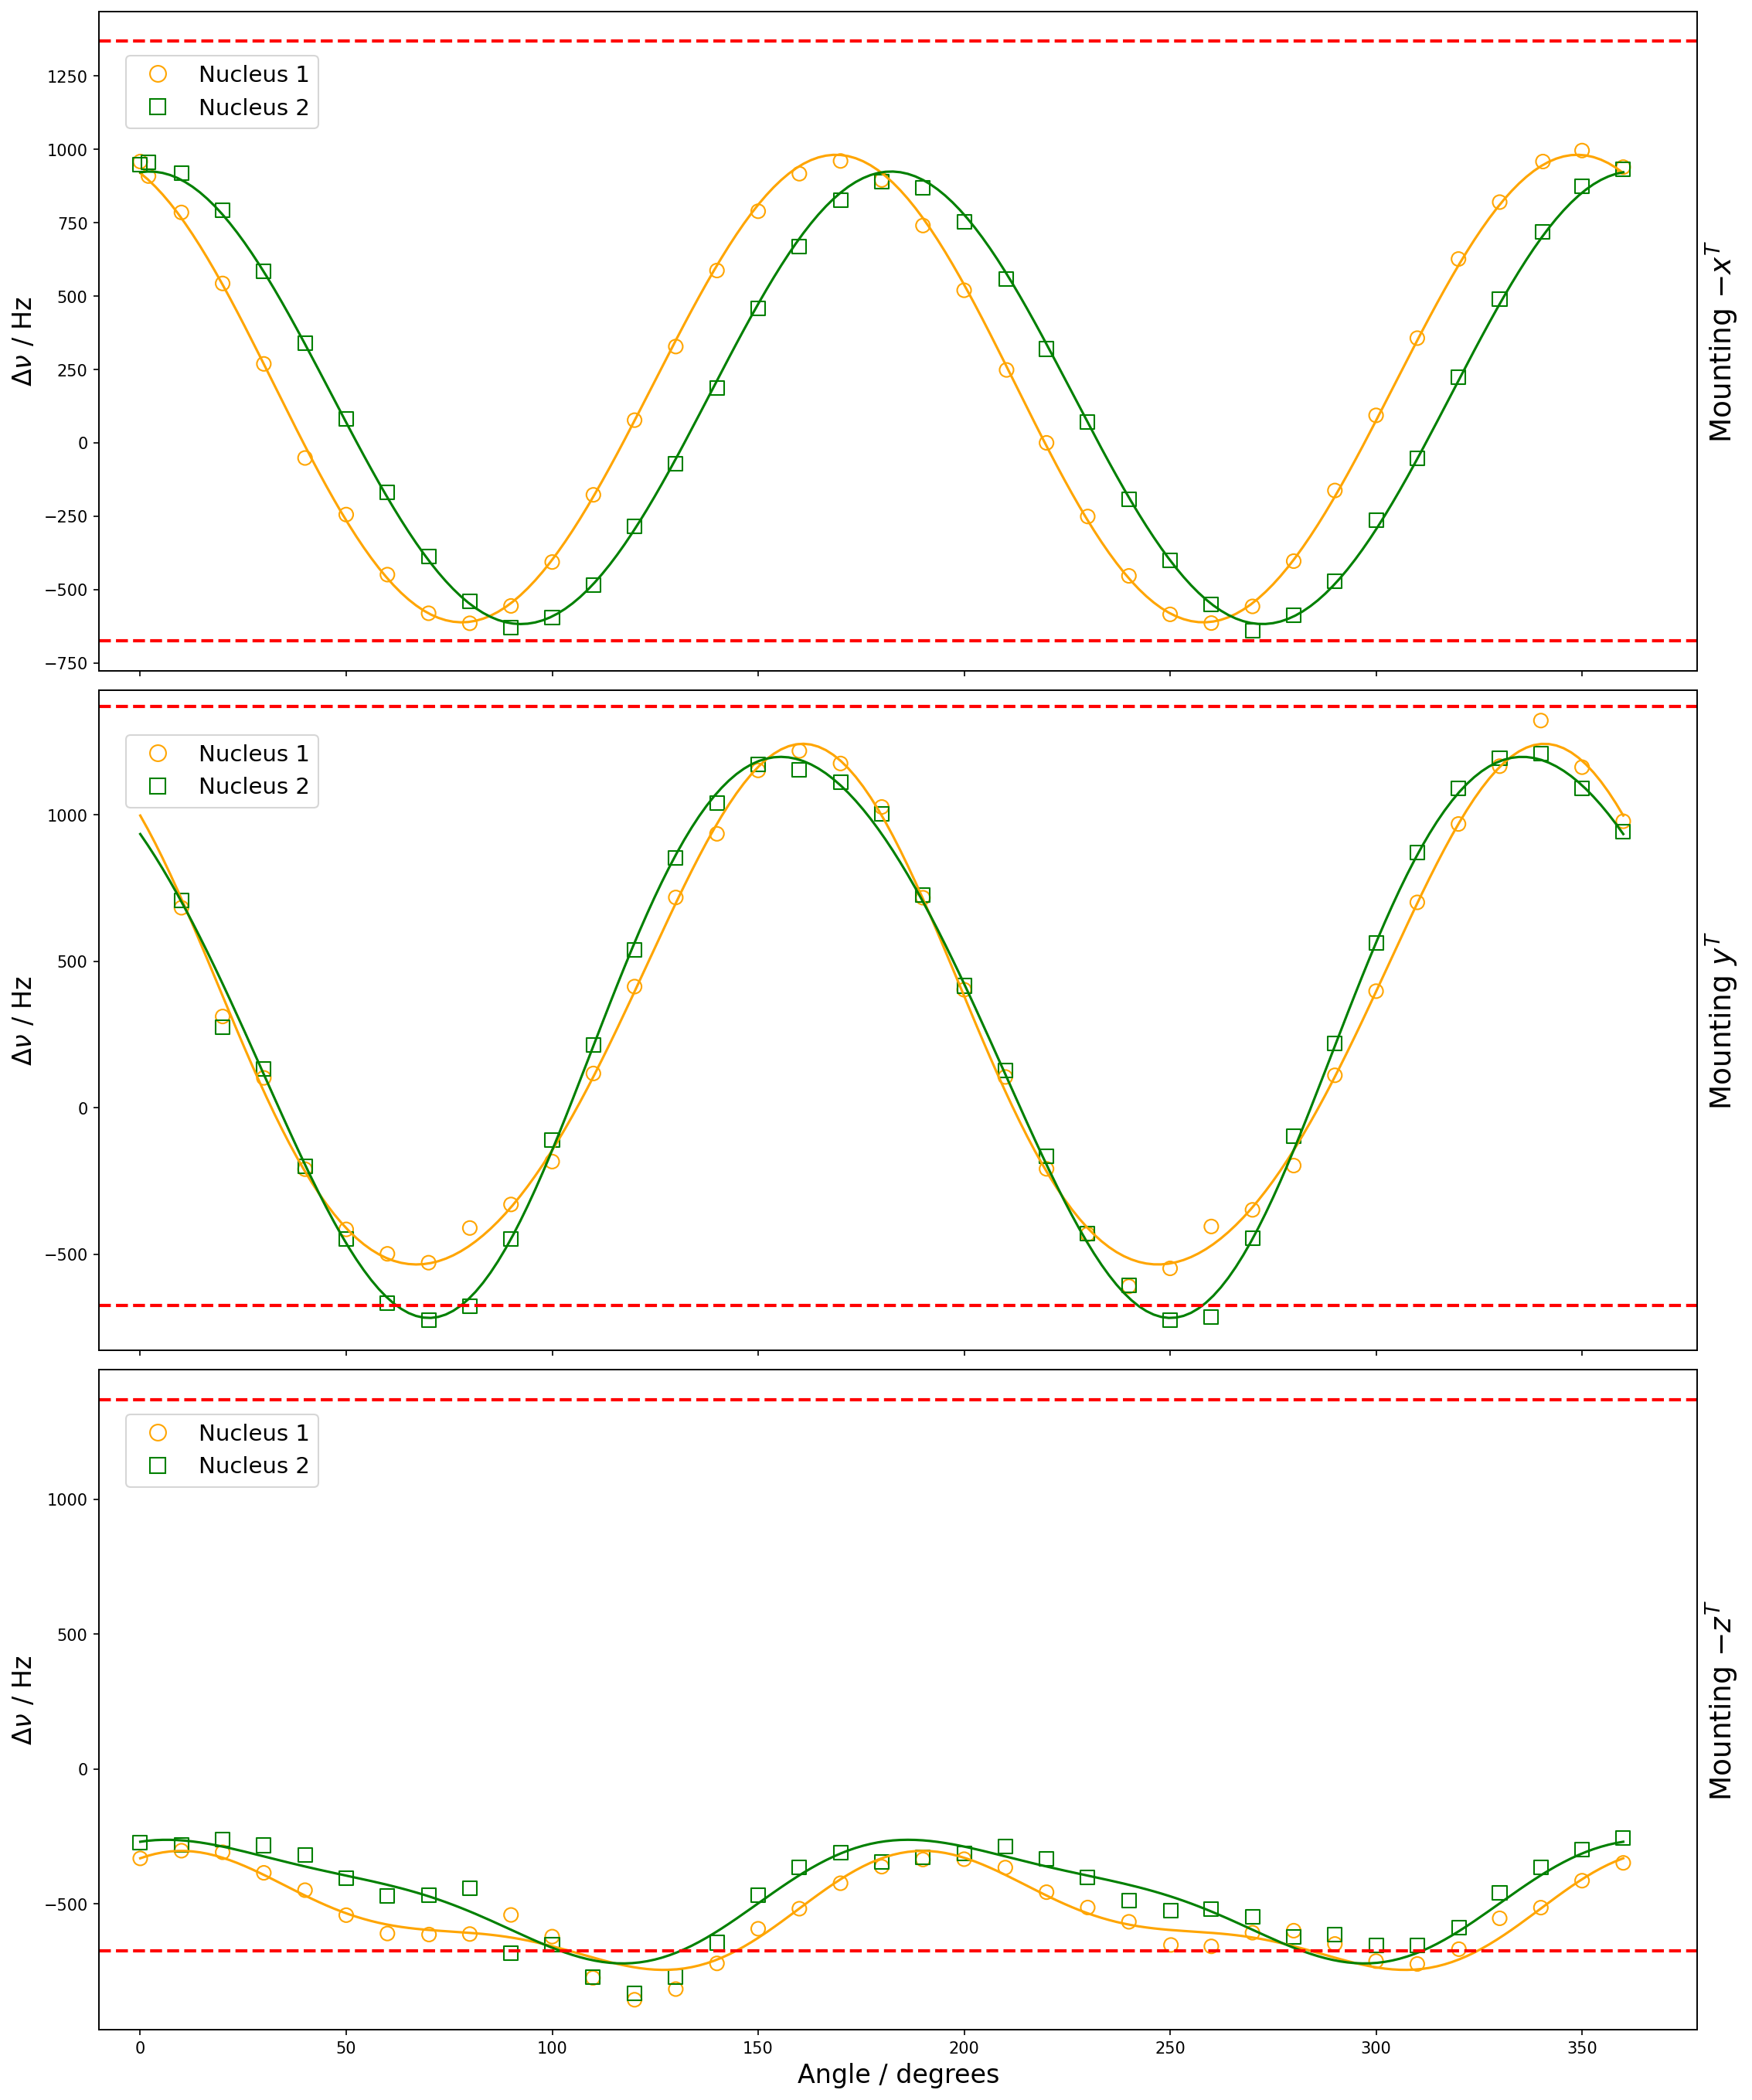

In [20]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)


for i in range (3):
    # Fit data for both clusters
    params1, _ = curve_fit(fourier5, df[i].Angle, df[i].J_Cluster1*w0)
    params2, _ = curve_fit(fourier5, df[i].Angle, df[i].J_Cluster2*w0)
    
    print(params1, params2) # Print parameters
    
    axes[i].scatter(df[i].Angle, df[i].J_Cluster1*w0, marker='o', s=75, facecolor='none', edgecolor='orange') #frequency in Hz

    axes[i].scatter(df[i].Angle, df[i].J_Cluster2*w0,  marker='s', s=75, facecolor='none', edgecolor='green') #frequency in Hz

    # Fit curve plot
    axes[i].plot(angle_smooth, fourier5(angle_smooth, *params1[:5]), label='Fit Cluster 1', color='orange')
    axes[i].plot(angle_smooth, fourier5(angle_smooth, *params2[:5]), label='Fit Cluster 2', color='green')
    
    # Plot max and min range for N satellite splitting
    axes[i].axhline(y= J_iso + (RDD_BN-J_aniso/3), color='r', linestyle='--', linewidth=2)  # Horizontal line at y=JBN + DBN
    axes[i].axhline(y= J_iso - 2*(RDD_BN-J_aniso/3), color='r', linestyle='--', linewidth=2)  # Horizontal line at y=JBN - 2*DBN
    
    # Left-side label for Chemical Shift (only on axes[0])
    axes[i].set_ylabel(r'$\Delta \nu$ / Hz', fontsize=16)
    
    # Add a single legend with both markers and lines, placed side by side
    axes[i].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0.01, 0.95), fontsize = 14, ncol=1)
    

# Set x-axis label
plt.xlabel('Angle / degrees', fontsize=16)


# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel(r'Mounting $-x^T$', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel(r'Mounting $y^T$', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel(r'Mounting $-z^T$', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='orange', markersize=10, label='Nucleus 1'),
    Line2D([0], [0], marker='s', linestyle='None', markerfacecolor='none', markeredgecolor='green', markersize=10, label='Nucleus 2'),
]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2


ax0_twin.set_xlim(left=-10)

# plt.legend()
Fig.savefig('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/LHQ_J_rotation_plot.png', dpi = 150 ,bbox_inches='tight')

# Show the plot
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster2Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster2Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# Custom legend handle ( markers)
# marker_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
#                  Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
#                  Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=8, label='Mounting 3')]

# Custom legend for lines
line_legend = [Line2D([0], [0], color='grey', lw=1, marker = 'o', linestyle='', markersize=8, markerfacecolor = 'blue',  label='Site 1'), 
               Line2D([0], [0], color='grey', lw=1,marker = '^', linestyle='', markersize=8, markerfacecolor = 'blue', label='Site 2')]

# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend =  line_legend
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=2)

# plt.title(r'Mounting 1 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=3)



plt.title(r'$(-,-)8HQ(ipc)_2B$ Site 1 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[2].Angle, df[2].Cluster2Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)



plt.title(r'$(-,-)8HQ(ipc)_2B$ Site 2 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()

In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
plt.plot(df[2].Angle, df[2].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=8, label='Site 1'),
                 Line2D([0], [0], marker='^', color='w', markerfacecolor='grey', markersize=8, label='Site 2')]



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=2)



plt.title(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()


In [ ]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=2, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Site 1 data****************************
axes[0].plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[0].plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[0].plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Plot Site 2 data****************************
axes[1].plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='--', marker='s', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[1].plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='--', marker='s', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[1].plot(df[2].Angle, df[2].Cluster2Peak1, linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Set x-axis label
plt.xlabel('Angle /degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift /ppm', fontsize=16)
axes[1].set_ylabel('Chemical Shift /ppm', fontsize=16)

# Right-side labels for Site 1 and Site 2 using twin axes
ax0_twin = axes[0].twinx()

ax0_twin.set_ylabel('Site 1', fontweight='bold', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel('Site 2', fontweight='bold', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
ax0_twin.set_xlim(left=-10)

# Save the plot to a specific folder
folder_path = '/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/'  # Replace with the actual folder path
file_name = 'LHQ_site1_site2.png'
plt.savefig(folder_path + file_name, dpi=150, bbox_inches='tight')

# Show the plot
plt.show()


In [ ]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
axes[0].plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[0].plot(df[0].Angle, df[0].Cluster2Peak1,linestyle='--', marker='s', color = 'grey', markersize=8, markerfacecolor = 'blue')





# Plot Mount 2 data****************************

axes[1].plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[1].plot(df[1].Angle, df[1].Cluster2Peak1,linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = 'red')



# Plot Mount 2 data****************************

axes[2].plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

axes[2].plot(df[2].Angle, df[2].Cluster2Peak1, linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Set x-axis label
plt.xlabel('Angle /degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift /ppm', fontsize=16)
axes[1].set_ylabel('Chemical Shift /ppm', fontsize=16)
axes[2].set_ylabel('Chemical Shift /ppm', fontsize=16)

# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel('Mounting 1', fontweight='bold', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel('Mounting 2', fontweight='bold', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel('Mounting 3', fontweight='bold', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8, label='Site 1'),
                 Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markersize=8, label='Site 2'),
                 
                 ]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 0.06), ncol=23)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
axes[2].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
ax0_twin.set_xlim(left=-10)
# Show the plot
plt.show()


**For (+)8HQ**

In [14]:
D_HQ_x = [[-2.767572, -0.021837, -2.611411, 0.910820, 0.405120], [-0.902953 ,-1.814913, 0.661836, -0.373541, -0.493618]] # coefficient from ASICS
D_HQ_y = [[-3.845474 ,-0.065823 ,0.820338, 0.510270, 1.537412], [-2.045625, 0.688740, -1.907098, -0.481464, 0.489621]] # coefficient from ASICS
D_HQ_z = [[-1.865134 ,-1.927795 ,2.050566 ,0.604851, -0.045552], [-2.035060 ,-0.697897 ,0.778273 ,-0.288617 ,0.805603]] # coefficient from ASICS

# Fit for Mounting 1
D_HQ_1_x = fourier5(angle_smooth, *D_HQ_x[0]) # for amooth fit curve
D_HQ_2_x = fourier5(angle_smooth, *D_HQ_x[1])

# Fit for Mounting 2
D_HQ_1_y = fourier5(angle_smooth, *D_HQ_y[0])
D_HQ_2_y = fourier5(angle_smooth, *D_HQ_y[1])

# Fit for Mounting 3
D_HQ_1_z = fourier5(angle_smooth, *D_HQ_z[0])
D_HQ_2_z = fourier5(angle_smooth, *D_HQ_z[1])


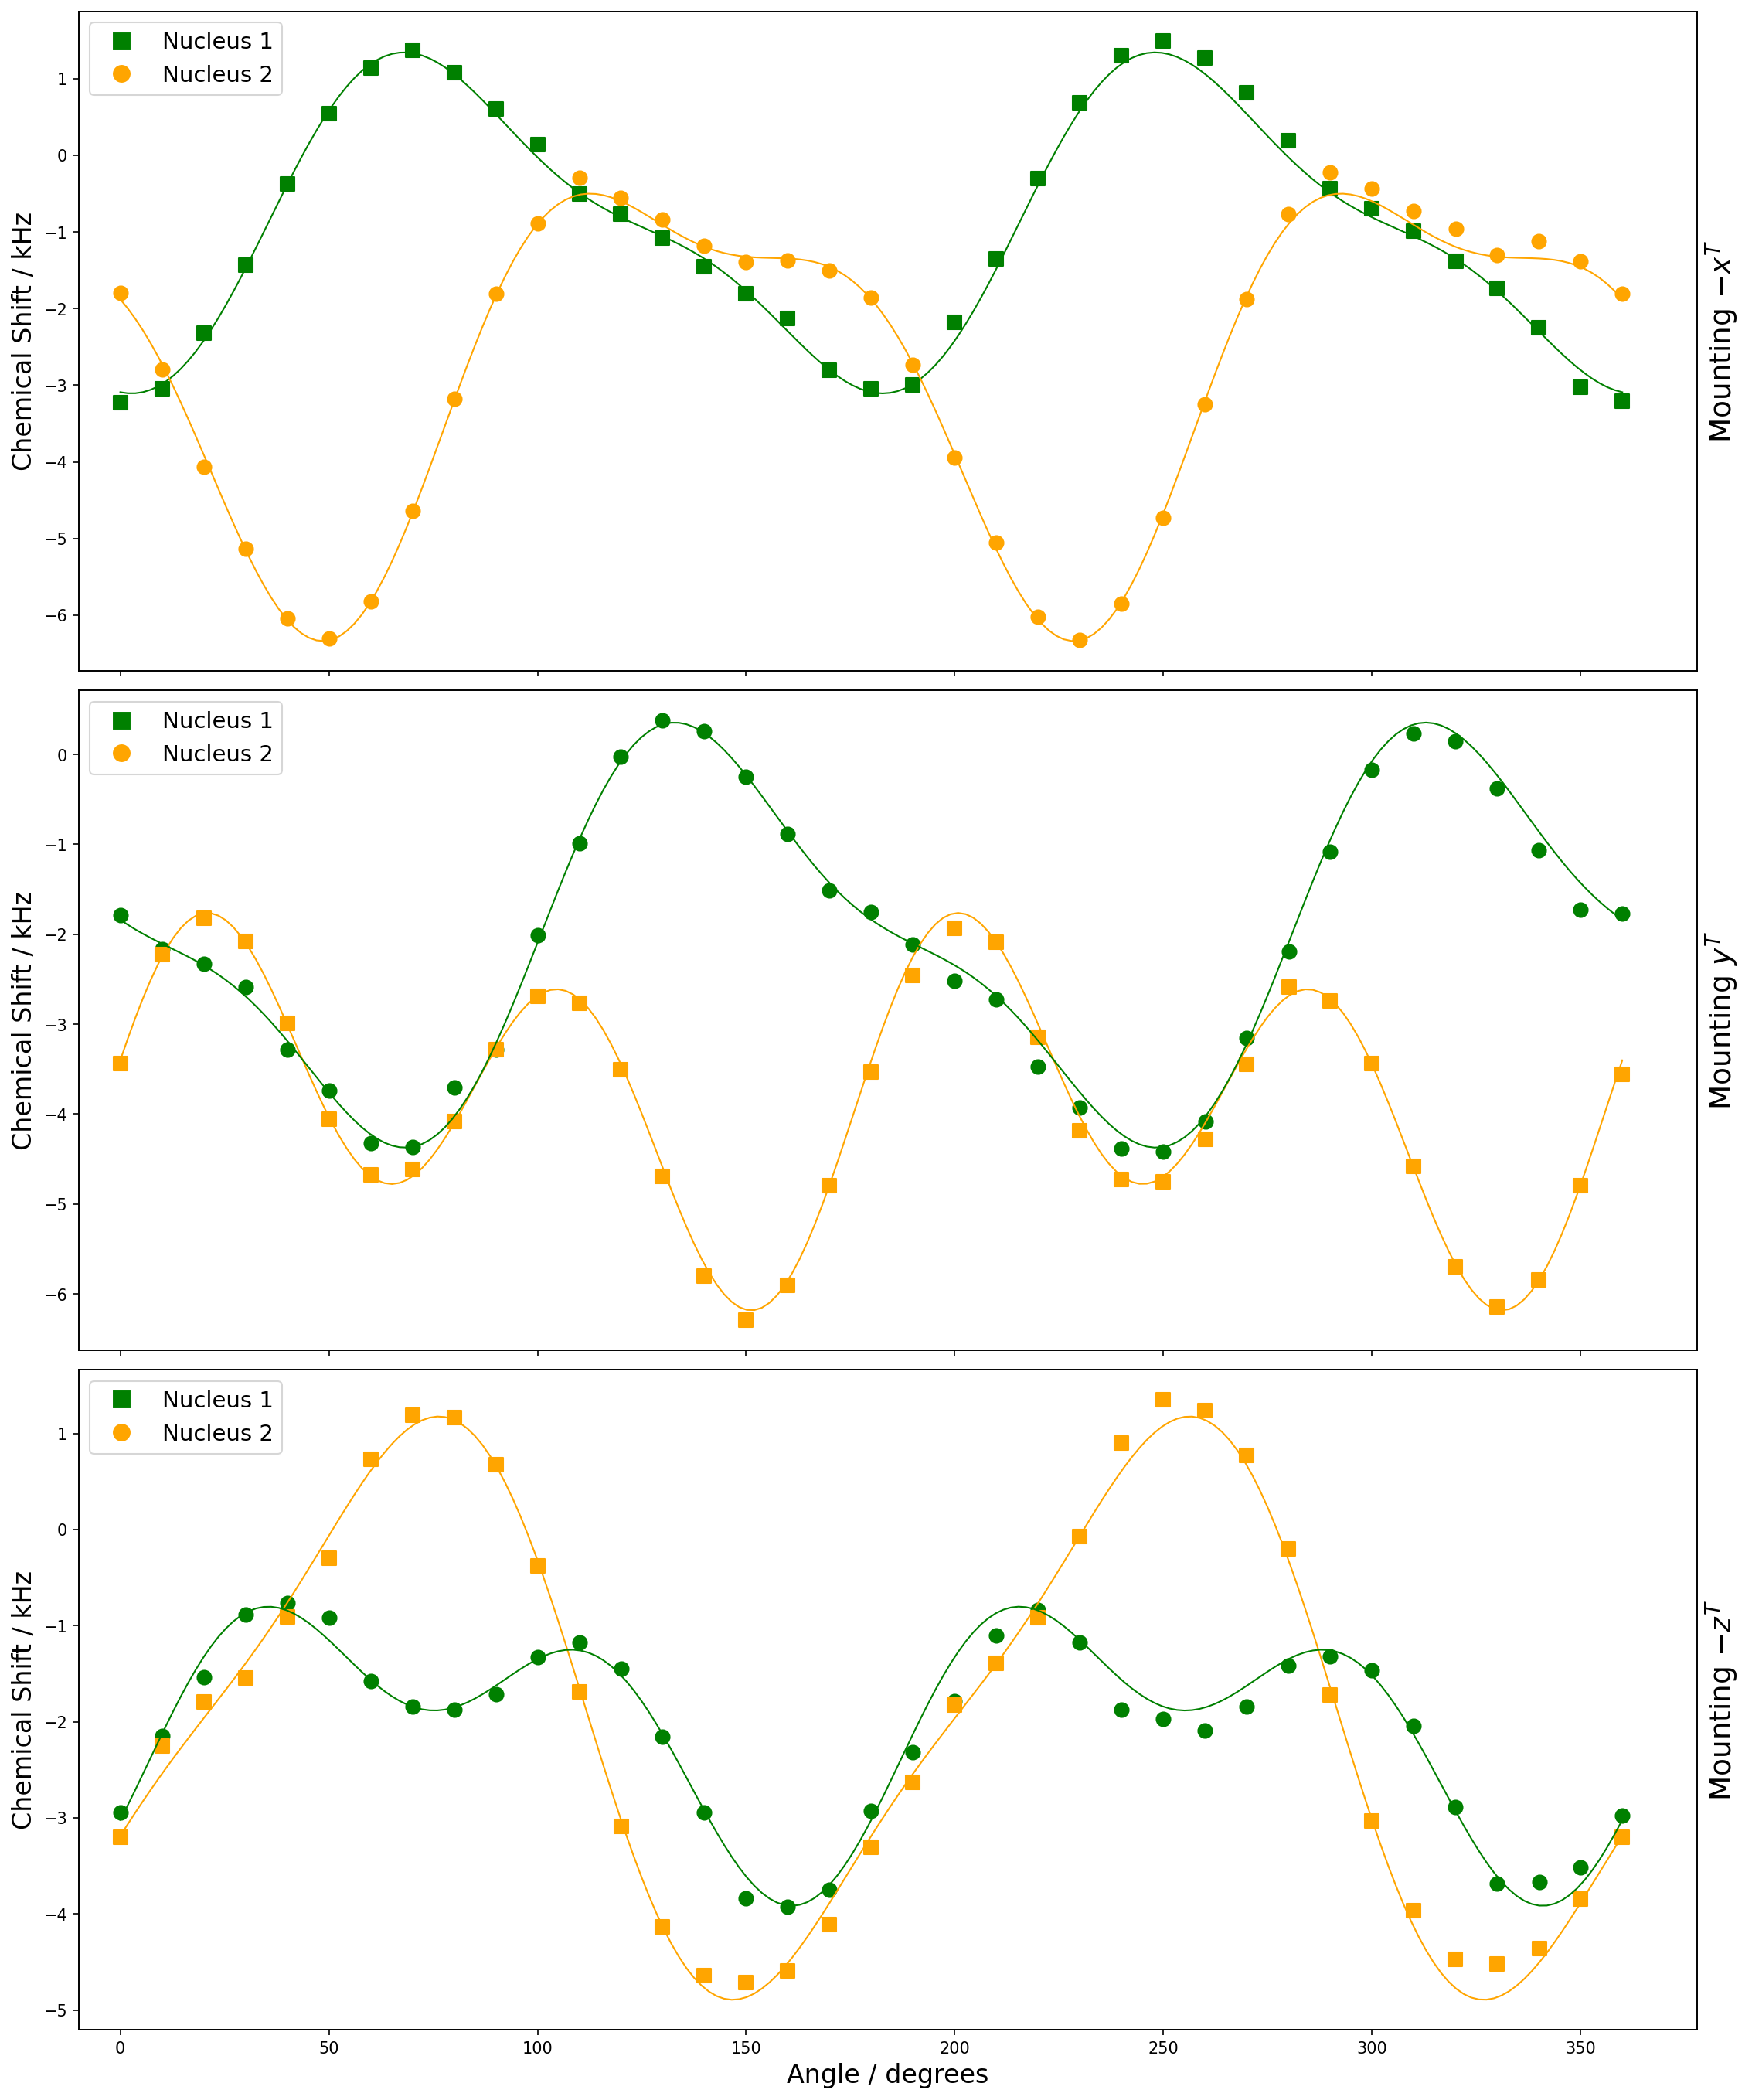

In [15]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
axes[0].scatter(df[3].Angle, df[3].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'orange') #frequency in kHz

axes[0].scatter(df[3].Angle, df[3].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'green') #frequency in kHz

axes[0].plot(angle_smooth, D_HQ_2_x,  color='green', lw = 1)

axes[0].plot(angle_smooth, D_HQ_1_x,  color='orange', lw = 1)



# Plot Mount 2 data****************************

axes[1].scatter(df[4].Angle, df[4].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'green') #frequency in kHz

axes[1].scatter(df[4].Angle, df[4].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'orange') #frequency in kHz

axes[1].plot(angle_smooth, D_HQ_1_y,  color='orange', lw = 1)

axes[1].plot(angle_smooth, D_HQ_2_y,  color='green', lw = 1)



# Plot Mount 3 data****************************

axes[2].scatter(df[5].Angle, df[5].Cluster1Peak1*w0/1000,  marker='o', s=75, c = 'green') #frequency in kHz

axes[2].scatter(df[5].Angle, df[5].Cluster2Peak1*w0/1000,  marker='s', s=75, c = 'orange') #frequency in kHz

axes[2].plot(angle_smooth, D_HQ_1_z,  color='orange', lw = 1)

axes[2].plot(angle_smooth, D_HQ_2_z,  color='green', lw = 1)

# Set x-axis label
plt.xlabel('Angle / degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[1].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[2].set_ylabel('Chemical Shift / kHz', fontsize=16)

# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel(r'Mounting $-x^T$', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel(r'Mounting $y^T$', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel(r'Mounting $-z^T$', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='green',  markersize=12, label='Nucleus 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=12, label='Nucleus 2'),
                 
                 ]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
axes[2].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=1)
ax0_twin.set_xlim(left=-10)
# Show the plot
Fig.savefig('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/DHQ_rotation_plot.png', dpi = 150 ,bbox_inches='tight')
plt.show()


**J Coupling**

[ 319.03564824 -808.84321501 -533.68323052   -4.97228187   53.15080232] [ 307.63148345 -475.75577738 -792.26889356   12.18914131  -23.40048883]
[-547.46771536   70.33005694   26.73742645   -7.10550392    7.28934376] [-406.45080293  233.13621804  -30.79018751   18.59940032   16.65378425]
[ 224.03284039 -901.96715724 -192.93168859   30.50822259  -73.68976209] [  73.37036393 -755.93839968  -63.20820764   60.99670292  -85.18250125]


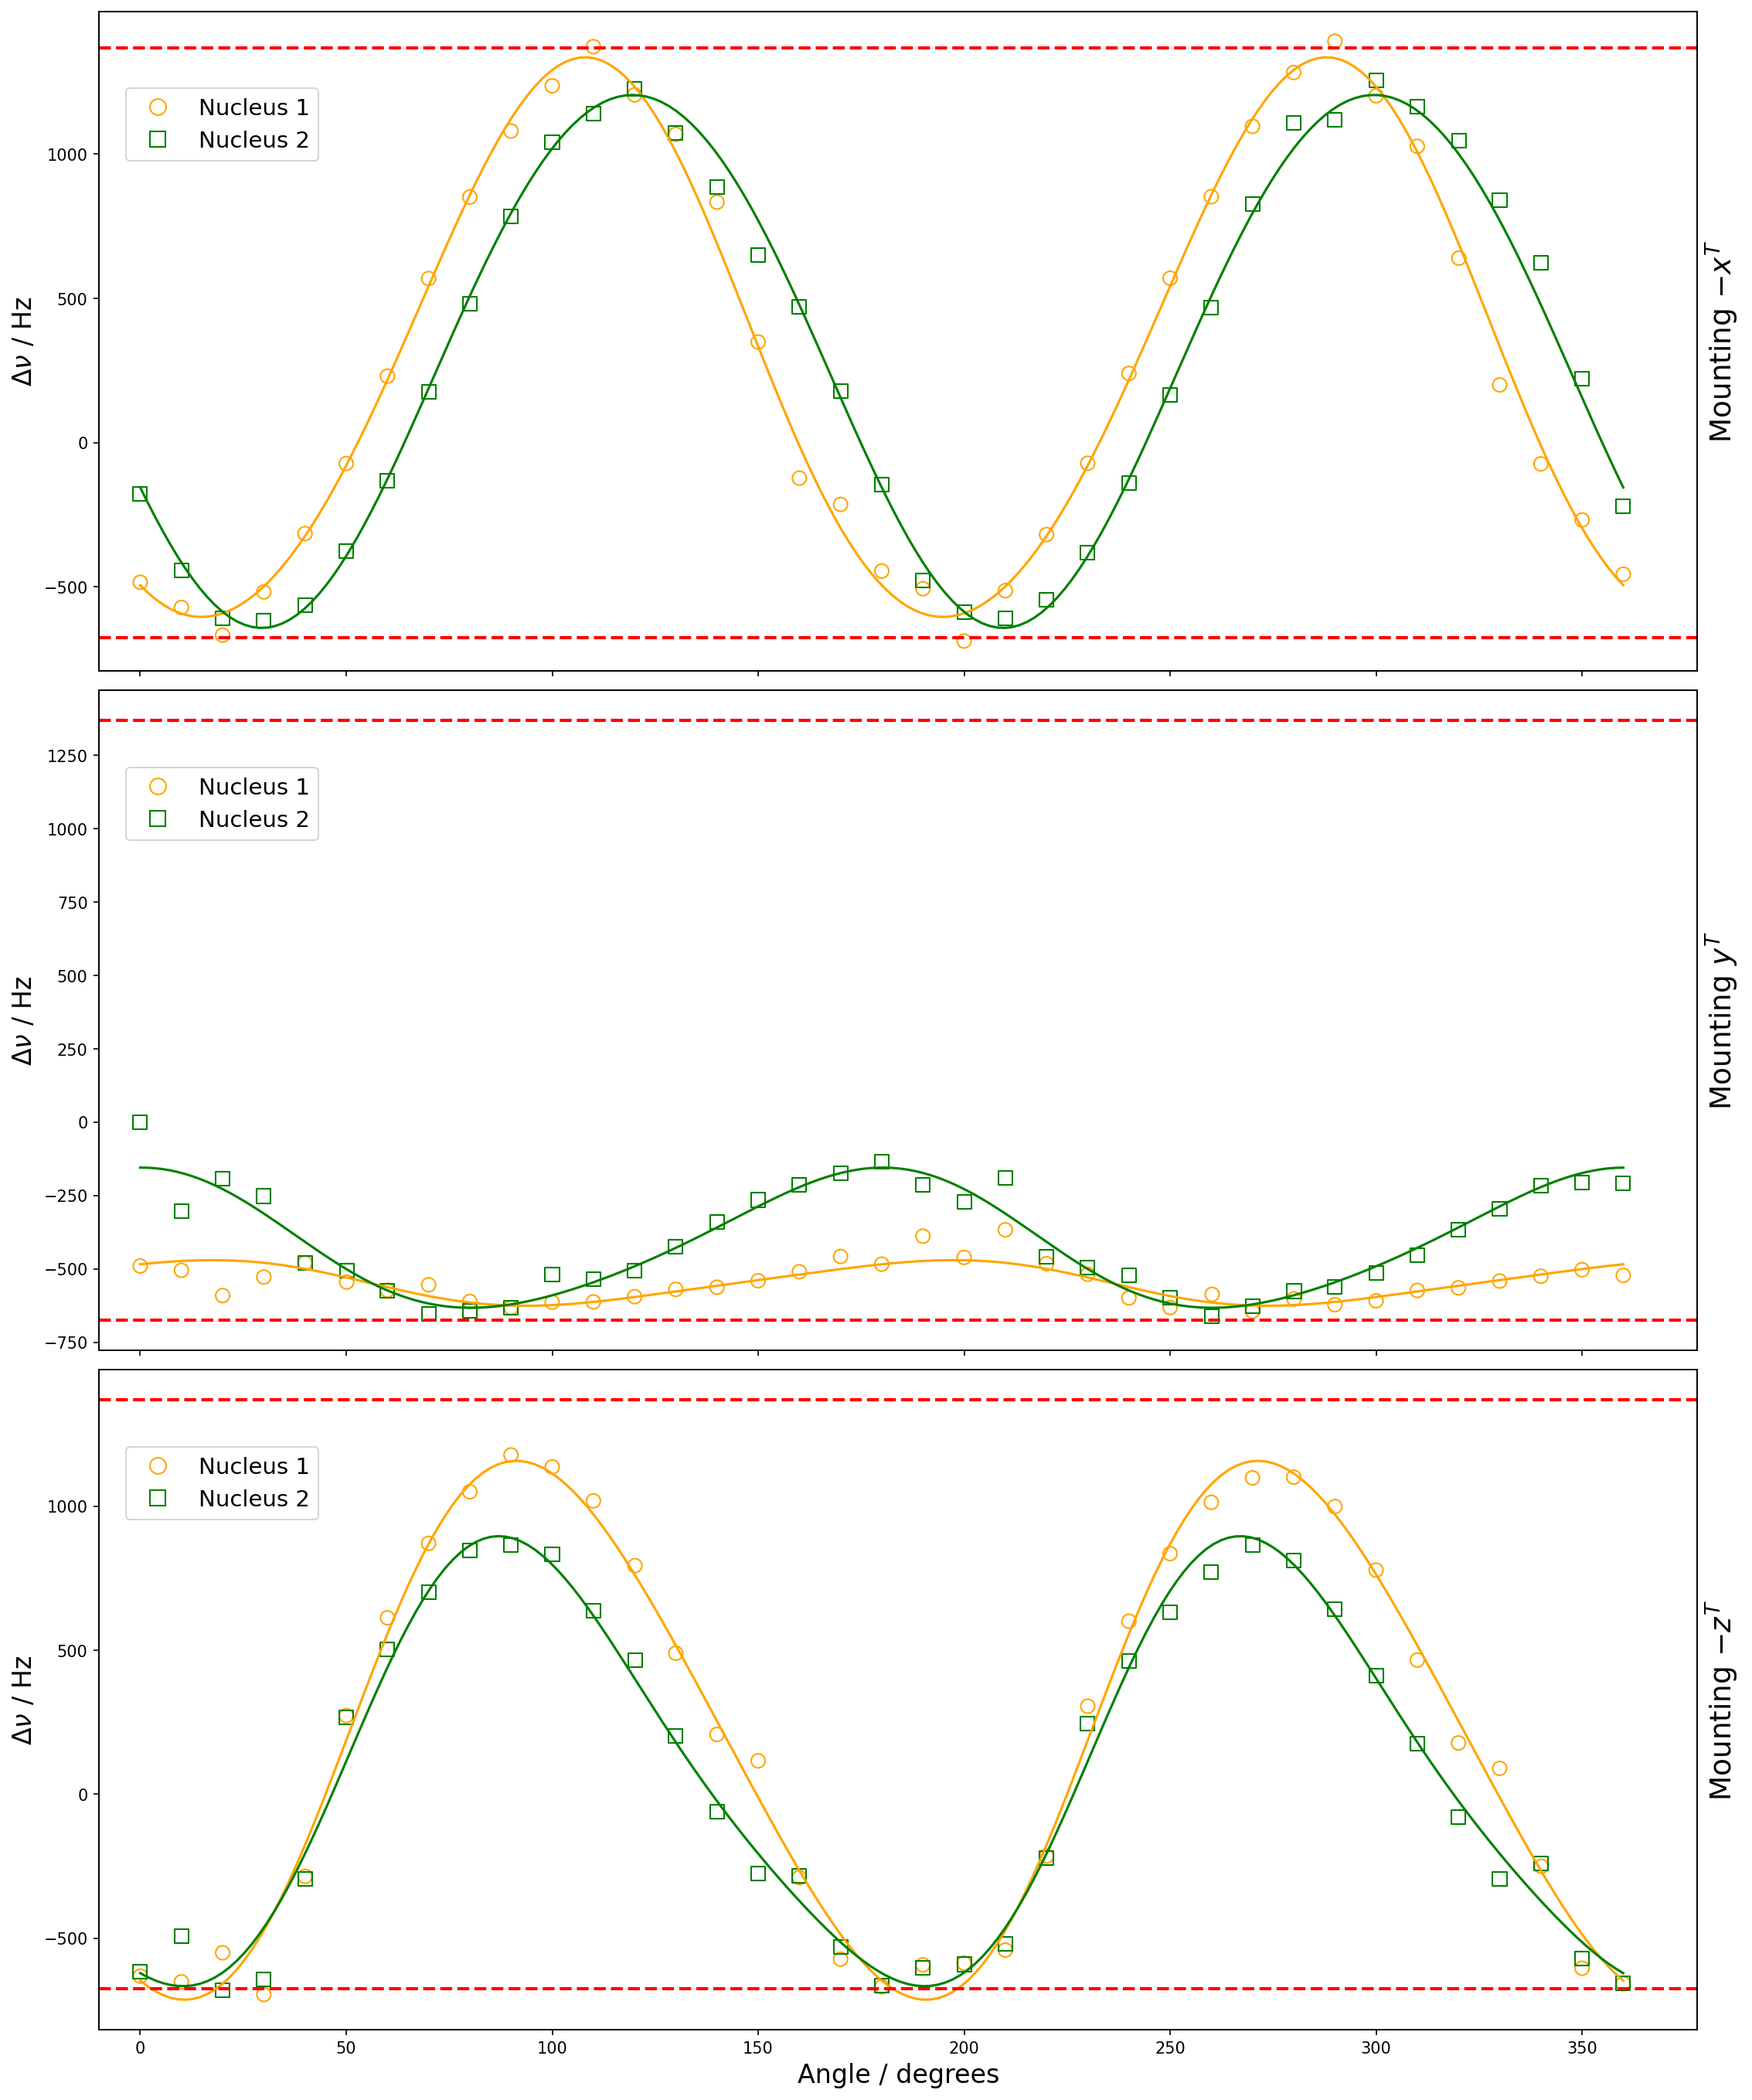

In [18]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)


for i in range (3,6):
    # Fit data for both clusters
    params1, _ = curve_fit(fourier5, df[i].Angle, df[i].J_Cluster1*w0)
    params2, _ = curve_fit(fourier5, df[i].Angle, df[i].J_Cluster2*w0)
    
    print(params1, params2) # Print parameters
    
    axes[i-3].scatter(df[i].Angle, df[i].J_Cluster1*w0, marker='o', s=75, facecolor='none', edgecolor='orange') #frequency in Hz

    axes[i-3].scatter(df[i].Angle, df[i].J_Cluster2*w0,  marker='s', s=75, facecolor='none', edgecolor='green') #frequency in Hz

    # Fit curve plot
    axes[i-3].plot(angle_smooth, fourier5(angle_smooth, *params1[:5]), label='Fit Cluster 1', color='orange')
    axes[i-3].plot(angle_smooth, fourier5(angle_smooth, *params2[:5]), label='Fit Cluster 2', color='green')
    
    # Plot max and min range for N satellite splitting
    axes[i -3].axhline(y= J_iso + (RDD_BN-J_aniso/3), color='r', linestyle='--', linewidth=2)  # Horizontal line at y=JBN + DBN
    axes[i -3].axhline(y= J_iso - 2*(RDD_BN-J_aniso/3), color='r', linestyle='--', linewidth=2)  # Horizontal line at y=JBN - 2*DBN
    
    # Left-side label for Chemical Shift (only on axes[0])
    axes[i-3].set_ylabel(r'$\Delta \nu$ / Hz', fontsize=16)
    
    # Add a single legend with both markers and lines, placed side by side
    axes[i-3].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0.01, 0.9), fontsize = 14, ncol=1)
    

# Set x-axis label
plt.xlabel('Angle / degrees', fontsize=16)


# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel(r'Mounting $-x^T$', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel(r'Mounting $y^T$', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel(r'Mounting $-z^T$', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='orange', markersize=10, label='Nucleus 1'),
    Line2D([0], [0], marker='s', linestyle='None', markerfacecolor='none', markeredgecolor='green', markersize=10, label='Nucleus 2'),
]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2


ax0_twin.set_xlim(left=-10)

# plt.legend()
Fig.savefig('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/DHQ_J_rotation_plot.png', dpi = 150 ,bbox_inches='tight')

# Show the plot
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[3].Angle, df[3].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[4].Angle, df[4].Cluster2Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[5].Angle, df[5].Cluster2Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=3)



plt.title(r'$(+,+)8HQ(ipc)_2B$ Site 2 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()

In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[3].Angle, df[3].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[4].Angle, df[4].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[5].Angle, df[5].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=3)



plt.title(r'$(+,+)8HQ(ipc)_2B$ Site 1 Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()


In [ ]:
plt.figure(figsize = (15,10), dpi = 300)

# plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[3].Angle, df[3].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')
plt.plot(df[3].Angle, df[3].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = 'blue')
# plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

# plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[4].Angle, df[4].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')
plt.plot(df[4].Angle, df[4].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = 'red')
# plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

# plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'cyan')
plt.plot(df[5].Angle, df[5].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')
plt.plot(df[5].Angle, df[5].Cluster2Peak1,linestyle='-', marker='^', color = 'grey', markersize=8, markerfacecolor = '#df65b0')
# plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'cyan')

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = [Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=8, label='Site 1'),
                 Line2D([0], [0], marker='^', color='w', markerfacecolor='grey', markersize=8, label='Site 2')]



# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=2)



plt.title(r'$(+,+)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)
plt.xlabel('Angle /degrees', fontsize=16)
plt.ylabel('Chemical Shift /ppm', fontsize=16)
# plt.grid()
plt.show()

In [ ]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=2, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(+,+)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Site 1 data****************************
axes[0].plot(df[3].Angle, df[3].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[0].plot(df[4].Angle, df[4].Cluster1Peak1,linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[0].plot(df[5].Angle, df[5].Cluster1Peak1, linestyle='--', marker='o', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Plot Site 2 data****************************
axes[1].plot(df[3].Angle, df[3].Cluster2Peak1,linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor = 'blue')

axes[1].plot(df[4].Angle, df[4].Cluster2Peak1,linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = 'red')

axes[1].plot(df[5].Angle, df[5].Cluster2Peak1, linestyle='--', marker='^', color = 'grey', markersize=8, markerfacecolor  = '#df65b0')

# Set x-axis label
plt.xlabel('Angle /degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift /ppm', fontsize=16)
axes[1].set_ylabel('Chemical Shift /ppm', fontsize=16)

# Right-side labels for Site 1 and Site 2 using twin axes
ax0_twin = axes[0].twinx()

ax0_twin.set_ylabel('Site 1', fontweight='bold', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel('Site 2', fontweight='bold', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='s', color='w', markerfacecolor='#df65b0', markersize=8, label='Mounting 3')]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=23)
ax0_twin.set_xlim(left=-5) # start x-axes from 0


# Save the plot to a specific folder
folder_path = '/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/'  # Replace with the actual folder path
file_name = 'DHQ_site1_site2.png'
plt.savefig(folder_path + file_name, dpi=150, bbox_inches='tight')

# Show the plot
plt.show()
